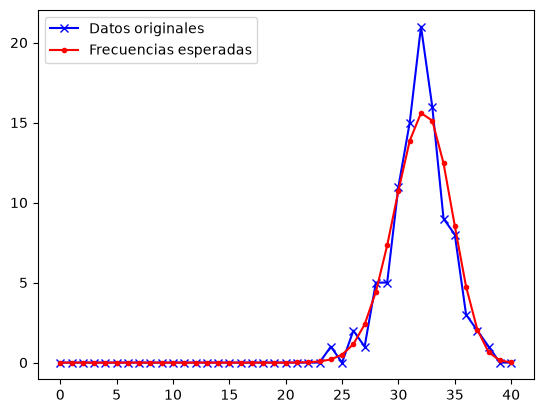

Valor de chi2:4.093052111501798, Valor de p: 0.6640854275848114, Número de grados de libertad: 6
Divergenecia de Kullback-Leibler en bits: 0.0680389655753677


In [1]:
import numpy as np
from scipy.stats import binom, chisquare, power_divergence, kstest
from statsmodels.stats.diagnostic import lilliefors

import matplotlib.pyplot as plt

# ==========================================================
# Parámetros
# ==========================================================
n = 40          # Parámetro Binomial
p = 0.80        # Probabilidad real
N = 100         # Número de muestras

# ==========================================================
# Generar datos
# ==========================================================
datos = np.random.binomial(n=n, p=p, size=N)+np.random.choice(a=[-1,1,0], p=[0.2,0.2,0.6], size=N)

# ==========================================================
# Frecuencias observadas
# ==========================================================
k = np.arange(n + 1)
obs = np.bincount(datos, minlength=n + 1)
p_empirica = obs / np.sum(obs) #Necesaria para la divergencia de Kullback-Leibler
plt.plot(k,obs,'-xb', label='Datos originales')

# ==========================================================
# Frecuencias esperadas
# ==========================================================
prob = binom.pmf(k, n=n, p=p)
q_teorica=prob #Necesaria para la divergencia de Kulback-Leibler
esp = N * prob
plt.plot(k,esp,'.r-', label='Frecuencias esperadas')
plt.legend()
plt.show()

# ==========================================================
# Agrupar automáticamente categorías con frecuencia esperada < 5
# ==========================================================
obs2 = []
esp2 = []
o = 0
e = 0

for oi, ei in zip(obs, esp):
    o += oi
    e += ei
    if e >= 5:
        obs2.append(o)
        esp2.append(e)
        o = 0
        e = 0

# Si quedaron categorías al final
if e > 0:

    obs2[-1] += o
    esp2[-1] += e

obs2 = np.array(obs2)
esp2 = np.array(esp2)

# ==========================================================
# Chi-cuadrado
# ==========================================================
num_params = 2
chi2, p = power_divergence(
    obs2,
    esp2,
    lambda_="pearson",
    ddof=num_params
)
gl = len(obs2) - 1 - num_params
print(f'Valor de chi2:{chi2}, Valor de p: {p}, Número de grados de libertad: {gl}')

kl = np.sum(
    [pi * np.log2(pi/qi)
     for pi, qi in zip(p_empirica, q_teorica)
     if pi > 0]
)

print("Divergenecia de Kullback-Leibler en bits:", kl)


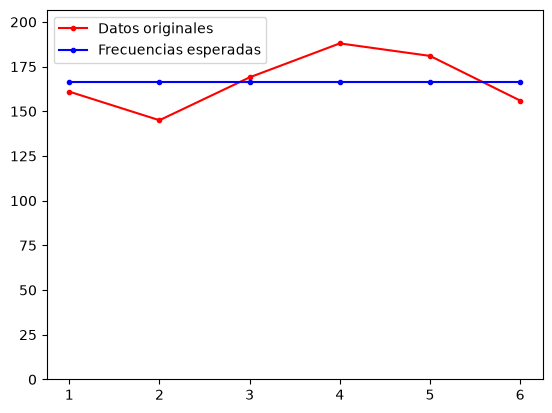

Valor de chi2:7.688000000000001, Valor de p: 0.0529196902561103, Número de grados de libertad: 3
Divergenecia de Kullback-Leibler en bits: 0.005548832039344002


In [6]:
# Ajuste de una distribución uniforme

# ==========================================================
# Parámetros
# ==========================================================
n = 6          # Parámetro Binomial
p = 1/6        # Probabilidad real
N = 1000         # Número de muestras

# ==========================================================
# Generar datos
# ==========================================================

datos = np.random.randint(low=1, high=n+1, size=N)
# ==========================================================
# Frecuencias observadas
# ==========================================================

k, obs = np.unique(datos, return_counts=True)
p_empirica = obs / np.sum(obs) #Necesaria para la divergencia de Kullback-Leibler
plt.plot(k,obs,'.r-', label='Datos originales')
# ==========================================================
# Frecuencias esperadas
# ==========================================================

prob = np.array([1/n for i in range(n)])
q_teorica=prob #Necesaria para la divergencia de Kulback-Leibler
#print(prob)
esp = N * prob
plt.plot(k,esp,'.b-', label='Frecuencias esperadas')
plt.legend()
plt.ylim(0,max(obs)*1.1)
plt.show()

# ==========================================================
# Agrupar automáticamente categorías con frecuencia esperada < 5
# ==========================================================
obs2 = []
esp2 = []
o = 0
e = 0

for oi, ei in zip(obs, esp):
    o += oi
    e += ei
    if e >= 5:
        obs2.append(o)
        esp2.append(e)
        o = 0
        e = 0

# Si quedaron categorías al final
if e > 0:

    obs2[-1] += o
    esp2[-1] += e

obs2 = np.array(obs2)
esp2 = np.array(esp2)

# ==========================================================
# Chi-cuadrado
# ==========================================================
num_params = 2
chi2, p = power_divergence(
    obs2,
    esp2,
    lambda_="pearson",
    ddof=num_params
)
gl = len(obs2) - 1 - num_params
print(f'Valor de chi2:{chi2}, Valor de p: {p}, Número de grados de libertad: {gl}')

kl = np.sum(
    [pi * np.log2(pi/qi)
     for pi, qi in zip(p_empirica, q_teorica)
     if pi > 0]
)

print("Divergenecia de Kullback-Leibler en bits:", kl)

p=0.10261672652642381, N=200
Los valores de las clases de x: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65]


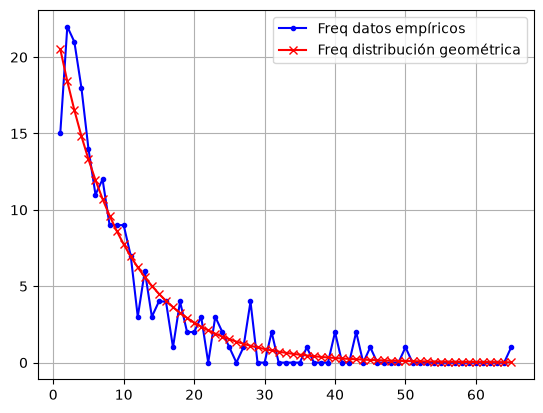

In [12]:
# Ensayemos estos datos con distribución geométrica, hagamos el ajuste a dicha distribución
# Estos datos representan el número de ensayos hasta un éxito
datos = [
    2, 7, 45, 4, 5, 13, 14, 2, 18, 15, 2, 28, 11, 1, 16, 6, 20, 8, 1, 1, 3, 10, 8, 4, 8, 5, 4, 3, 4, 2, 17, 23, 31, 13, 16, 11, 21, 7, 1, 5,
    23, 11, 31, 6, 5, 5, 4, 1, 8, 2, 1, 10, 1, 9, 10, 5, 12, 40, 21, 4, 1, 13, 8, 12, 2, 13, 6, 2, 2, 12, 3, 14, 6, 3, 43, 1, 2, 8, 10, 10,
    3, 4, 8, 2, 3, 4, 2, 10, 6, 1, 4, 15, 28, 5, 6, 3, 36, 3, 2, 3, 6, 5, 7, 7, 19, 13, 6, 3, 3, 2, 16, 20, 10, 1, 18, 3, 13, 15, 9, 8,
    3, 7, 10, 1, 7, 4, 3, 7, 27, 18, 8, 24, 4, 9, 9, 9, 10, 11, 24, 3, 3, 14, 4, 2, 1, 4, 1, 5, 4, 5, 2, 7, 9, 3, 2, 5, 23, 40, 28, 16,
    11, 2, 19, 4, 15, 7, 28, 25, 11, 2, 2, 4, 2, 18, 1, 9, 7, 2, 6, 21, 9, 6, 5, 7, 6, 3, 43, 50, 7, 9, 5, 4, 4, 3, 11, 2, 3, 5, 65, 3
]

# Distribución geométrica: 
p=1/np.mean(datos)
N=len(datos)
print(f'p={p}, N={N}')
x=list(range(1,max(datos)+1))
print('Los valores de las clases de x:',x)

#Primero vamos a contar
def contador(datos, i): #Recibe los datos y devuelve el número de veces que aparece
    suma=0
    for xi in datos: 
        if xi==i:
            suma+=1
    return suma
    #return np.sum([1 if xi==i else 0 for xi in datos])

freq_empirica=[contador(datos, i) for i in x]
freq_teorica=[N*(1-p)**(i-1)*p     for i in x]
plt.plot(x, freq_empirica,'.b-', label='Freq datos empíricos')
plt.plot(x, freq_teorica,'xr-', label='Freq distribución geométrica')
plt.legend()
plt.grid()



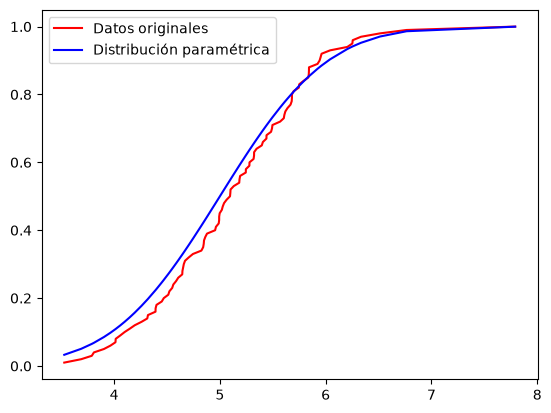

Estadístico de KS:  0.08750741895270048
P-value de KS:  0.404839077638522
Es mejor aplicar el estadístico de lilliefors, pues implica la estimación de los parámetros normales desde los datos empíricos
D: 0.0430407483298092
p-value de Lilliefors: 0.9263724435134931


In [10]:
# Ajuste de distribuciones contínuas, calculando el estadístico de Kolmogorov-Smirnov

# ==========================================================
# Parámetros de distribución normal
# ==========================================================
mu = 5          # Valor medio
sigma = 0.8        # Desviación estándar
N = 100         # Número de muestras

# ==========================================================
# Generar datos
# ==========================================================
datos = np.random.randn(N)*sigma+mu

# ==========================================================
# Distribución acumulada de los datos experimentales
# ==========================================================
datos = np.sort(datos)
N = len(datos)
F_emp = np.arange(1, N + 1) / N
plt.plot(datos, F_emp, 'r-', label='Datos originales')

# ==========================================================
# Distribución paramétrica normal
# ==========================================================
from scipy.stats import norm
F_teo = norm.cdf(datos, loc=mu, scale=sigma)
plt.plot(datos, F_teo, 'b-', label='Distribución paramétrica')
plt.legend()
plt.show()

# ==========================================================
# Estadístico de Kolmogorv Smirnov
# ==========================================================

resultado = kstest(
    datos,
    "norm",
    args=(mu, sigma)
)

print('Estadístico de KS: ',resultado.statistic)
print('P-value de KS: ',resultado.pvalue)

print('Es mejor aplicar el estadístico de lilliefors, pues implica la estimación de los parámetros normales desde los datos empíricos')
D, p_value = lilliefors(datos, dist="norm")
print("D:", D)
print("p-value de Lilliefors:", p_value)

In [11]:
# |Una mejor aproximación es calcular el parámetro p, por medio de una aproximación bootstrap:
from tqdm import tqdm
B = 5000

D_boot = np.zeros(B)

for b in tqdm(range(B)):

    # Simular
    muestra = np.random.normal(
        mu,
        sigma,
        size=N
    )

    # Reestimar parámetros
    mu_b = np.mean(muestra)
    sigma_b = np.std(muestra,ddof=0)

    # KS
    D_boot[b] = kstest(
        muestra,
        "norm",
        args=(mu_b,sigma_b)
    ).statistic

D_obs = kstest(
    datos,
    "norm",
    args=(mu,sigma)
).statistic

p_boot = np.mean(D_boot >= D_obs)

print(f'\n\nEstádistico de KS: {D_obs}, Valor p: {p_boot}')


100%|██████████| 5000/5000 [00:04<00:00, 1170.57it/s]



Estádistico de KS: 0.08750741895270048, Valor p: 0.0528


In [12]:
# Haga usted por favor el ajuste de la siguiente secuencia de datos a una distribución uniforme, contínua
datos = [
    7.08, 5.05, 9.13, 6.49, 6.84, 5.97, 7.83, 5.81, 5.62, 7.16, 7.81, 5.87, 7.77, 6.77, 9.79, 5.46, 9.89, 7.06, 7.52, 5.74,
    8.59, 5.95, 6.71, 5.12, 6.70, 9.84, 9.89, 8.72, 5.02, 9.70, 9.35, 8.85, 5.89, 5.50, 7.07, 9.43, 7.89, 8.68, 6.16, 7.62,
    8.55, 9.12, 9.04, 6.16, 9.37, 6.08, 9.01, 7.78, 5.93, 7.94, 7.59, 9.79, 5.21, 5.82, 9.92, 9.16, 5.75, 6.15, 7.70, 5.78,
    6.62, 5.25, 8.56, 5.39, 9.97, 9.60, 8.94, 8.86, 6.84, 8.39, 8.81, 7.40, 5.31, 8.13, 6.63, 8.05, 7.10, 9.76, 6.01, 8.84,
    8.49, 7.78, 5.40, 5.82, 9.84, 6.15, 5.82, 6.44, 7.69, 7.60, 5.02, 5.02, 7.48, 5.92, 8.04, 8.99, 5.48, 7.53, 7.03, 8.95,
    9.77, 7.08, 6.22, 9.39, 5.14, 6.65, 6.97, 5.89, 8.40, 7.59, 6.24, 7.07, 8.46, 6.62, 5.34, 7.30, 5.98, 8.11, 6.01, 5.68,
    9.47, 6.65, 6.46, 7.69, 8.47, 8.35, 8.99, 6.30, 7.13, 6.82, 7.58, 7.87, 8.15, 5.34, 6.86, 8.54, 5.18, 8.73, 8.43, 7.01,
    7.25, 6.32, 8.69, 7.40, 6.33, 5.15, 6.73, 9.60, 8.38, 8.13, 9.67, 5.15, 8.01, 5.94, 6.98, 5.91, 6.75, 9.51, 8.63, 9.23,
    5.38, 6.50, 8.92, 5.20, 5.95, 5.41, 9.09, 6.16, 7.12, 5.07, 5.57, 7.57, 8.96, 6.71, 6.60, 5.20, 5.50, 5.74, 6.03, 7.85,
    6.79, 9.89, 6.42, 9.28, 5.46, 7.64, 7.75, 8.29, 7.05, 7.62, 8.89, 5.76, 7.66, 7.94, 8.91, 5.82, 7.07, 5.12, 8.31, 9.34
]